# 04. Modelo Final e Conclusão

Este é o resultado final do case: a configuração escolhida no notebook 03, a avaliação no conjunto de teste e as principais conclusões.

## Estrutura deste notebook

1. **Interpretabilidade do modelo final** (seção 5): quais palavras pesam para cada categoria, com os coeficientes reais do modelo treinado aqui.
2. **Métrica de negócio** (seção 7): conecta a probabilidade prevista a uma decisão operacional concreta, que fração do catálogo poderia ser autoclassificada com segurança, liberando revisão humana só para os casos de baixa confiança.
3. **Plano mínimo de monitoramento** (seção 8): indicadores a acompanhar caso este modelo fosse para produção.
4. A seção de limitações reflete o que foi medido ao longo dos notebooks (duplicatas semânticas, significância estatística, sensibilidade à semente do UMAP), em vez de deixá-las como hipóteses não verificadas.

In [1]:
import sys
sys.path.append('./src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
import scipy.sparse as sp

from preprocessing import carregar_e_limpar, obter_ou_criar_split
from avaliacao import top_features_por_classe, cobertura_por_confianca, pr_auc_macro

import warnings
warnings.filterwarnings('ignore')

df = carregar_e_limpar('data/raw/dataset_ecommerce.csv')

le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx_train, idx_test = obter_ou_criar_split(df, y, caminho_split='data/processed/split.npz', test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]
texto_train = df['texto'].values[idx_train]
texto_test = df['texto'].values[idx_test]

## 1. Configuração escolhida

No notebook `03_modelagem_avaliacao.ipynb`, comparamos cinco modelos (Logistic Regression, Random Forest, Extra Trees, HistGradientBoosting e XGBoost) sobre três representações de texto: PCA e UMAP, cada uma em 10, 20 e 30 dimensões, e TF-IDF, em alta dimensão (5000 palavras, sem redução).

A melhor combinação da tabela inteira não envolveu embeddings: foi o TF-IDF com Logistic Regression. Depois de otimizar os dois melhores candidatos com Optuna (e de corrigir o vazamento na validação cruzada, e confirmar com um teste de significância estatística que a diferença entre os dois é real), a Logistic Regression com TF-IDF se manteve à frente. É essa configuração que segue para este notebook.

In [2]:
CONFIG_FINAL = {
    'representacao': 'TF-IDF',
    'dim': 5000,
    'modelo': 'Logistic Regression',
    'hiperparametros': {
        'C': 5.179554356516547,
        'class_weight': 'balanced',
        'max_iter': 2000,
        'random_state': 42,
    },
}
CONFIG_FINAL

{'representacao': 'TF-IDF',
 'dim': 5000,
 'modelo': 'Logistic Regression',
 'hiperparametros': {'C': 5.179554356516547,
  'class_weight': 'balanced',
  'max_iter': 2000,
  'random_state': 42}}

## 2. Treinar o modelo final

In [3]:
tfidf_final = TfidfVectorizer(max_features=5000, min_df=2)
X_train_final = tfidf_final.fit_transform(texto_train)
X_test_final = tfidf_final.transform(texto_test)

modelo_final = LogisticRegression(**CONFIG_FINAL['hiperparametros'])
modelo_final.fit(X_train_final, y_train)
print("Modelo final treinado.")

Modelo final treinado.


## 3. Avaliação no teste

In [4]:
y_pred = modelo_final.predict(X_test_final)
y_proba = modelo_final.predict_proba(X_test_final)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
pr_auc = pr_auc_macro(y_test, y_proba, le.classes_)

print(f"Accuracy:    {acc * 100:.1f}%")
print(f"F1 Macro:    {f1_macro * 100:.1f}%")
print(f"F1 Weighted: {f1_weighted * 100:.1f}%")
print(f"ROC-AUC:     {roc_auc * 100:.1f}%")
print(f"PR-AUC macro:{pr_auc['macro'] * 100:.1f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy:    95.0%
F1 Macro:    94.9%
F1 Weighted: 95.0%
ROC-AUC:     99.1%
PR-AUC macro:97.8%

                      precision    recall  f1-score   support

               Books       0.94      0.93      0.94      1251
Clothing_Accessories       0.97      0.98      0.98      1135
         Electronics       0.93      0.93      0.93      1062
           Household       0.95      0.95      0.95      2113

            accuracy                           0.95      5561
           macro avg       0.95      0.95      0.95      5561
        weighted avg       0.95      0.95      0.95      5561



## 4. Matriz de confusão final

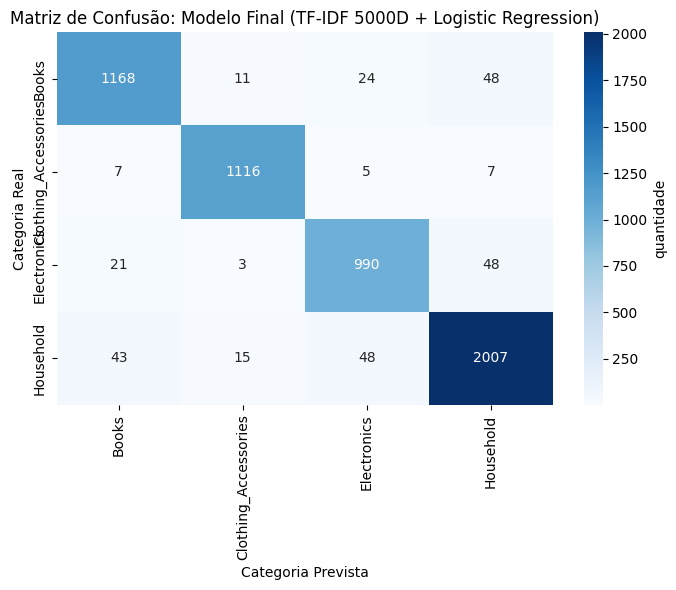

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'quantidade'})
ax.set_title(f"Matriz de Confusão: Modelo Final ({CONFIG_FINAL['representacao']} {CONFIG_FINAL['dim']}D + {CONFIG_FINAL['modelo']})")
ax.set_xlabel('Categoria Prevista')
ax.set_ylabel('Categoria Real')
plt.tight_layout()
plt.savefig('figs/04_matriz_confusao_final.png', dpi=100)
plt.show()

## 5. Interpretabilidade: o que o modelo está usando para decidir

Extraímos os coeficientes da Logistic Regression para o vocabulário do TF-IDF: cada valor mostra o quanto a presença daquela palavra desloca a previsão do modelo a favor (ou contra) cada categoria. Isso não é uma relação causal, é a direção e a força usadas pelo modelo linear para decidir, mas confirma (ou refutaria, se não fizesse sentido) a hipótese de que as categorias se distinguem por vocabulário característico.

In [6]:
top_palavras = top_features_por_classe(modelo_final, tfidf_final, le.classes_, top_n=10)
for classe, dados_classe in top_palavras.items():
    palavras_str = ', '.join(p for p, _ in dados_classe['a_favor'])
    print(f"{classe:22s} -> {palavras_str}")

print("\nAs palavras acima fazem sentido de negócio em todas as 4 categorias. Isso é evidência "
      "concreta a favor da hipótese de que o TF-IDF vence porque essas categorias têm vocabulário "
      "característico, não apenas uma suposição plausível.")

Books                  -> book, fishing, author, guide, game, action, how, training, education, oxford
Clothing_Accessories   -> women, men, sunglasses, boys, cotton, girls, bra, socks, jacket, unisex
Electronics            -> laptop, camera, lens, binoculars, cable, mount, tripod, hp, calculator, screen
Household              -> vacuum, door, bathrobe, chair, plastic, bathroom, home, kitchen, wallet, pillow

As palavras acima fazem sentido de negócio em todas as 4 categorias. Isso é evidência concreta a favor da hipótese de que o TF-IDF vence porque essas categorias têm vocabulário característico, não apenas uma suposição plausível.


## 6. Principais erros

In [7]:
erros = pd.DataFrame({
    'categoria_real': le.inverse_transform(y_test),
    'categoria_prevista': le.inverse_transform(y_pred),
})
apenas_erros = erros[erros['categoria_real'] != erros['categoria_prevista']]

pares = (apenas_erros.groupby(['categoria_real', 'categoria_prevista']).size()
         .reset_index(name='quantidade').sort_values('quantidade', ascending=False))
print(f"Taxa de erro geral: {len(apenas_erros) / len(erros) * 100:.1f}%")
display(pares.head(6))

Taxa de erro geral: 5.0%


,categoria_real,categoria_prevista,quantidade
2,Books,Household,48
11,Household,Electronics,48
8,Electronics,Household,48
9,Household,Books,43
1,Books,Electronics,24
6,Electronics,Books,21


## 7. Métrica de negócio: quanto do catálogo pode ser autoclassificado?

A probabilidade máxima de cada previsão (`probas_max`) só é útil se virar uma decisão operacional. Aqui simulamos uma regra de negócio simples: "acima de um threshold de confiança, aceita a previsão automática do modelo; abaixo disso, manda para revisão manual". Isso conecta a métrica de ML a um ganho de eficiência concreto, quantos produtos deixam de precisar de revisão humana. Também conecta a um risco concreto: a accuracy dos que sobram para revisão é sistematicamente pior, e é por isso que estão sendo mandados para lá.

,threshold,cobertura_autoclassificacao,n_autoclassificados,accuracy_autoclassificados,n_revisao_manual
0,0.50,98.2,5460,95.8,101
1,0.70,92.7,5153,97.3,408
2,0.80,87.8,4883,97.8,678
3,0.90,78.4,4360,98.6,1201
4,0.95,67.1,3729,98.9,1832
5,0.99,36.6,2036,99.4,3525


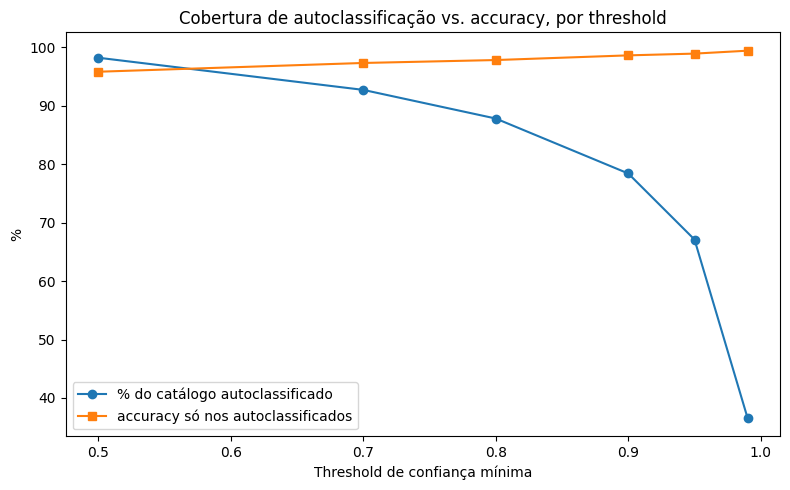


Exemplo de leitura: com threshold de 90% de confiança, 78.4% do catálogo poderia ser autoclassificado com 98.6% de accuracy nesse subconjunto, deixando 1201 produtos (de 5561 no conjunto de teste) para revisão manual.
Essa é a ponte que faltava entre a métrica de ML e uma decisão operacional: a escolha do threshold é uma decisão de negócio (quanto erro é aceitável automatizar vs. quanto custa a revisão manual), não uma decisão puramente estatística.


In [8]:
tabela_cobertura = cobertura_por_confianca(y_test, y_pred, y_proba, thresholds=(0.5, 0.7, 0.8, 0.9, 0.95, 0.99))
display(tabela_cobertura)

plt.figure(figsize=(8, 5))
plt.plot(tabela_cobertura['threshold'], tabela_cobertura['cobertura_autoclassificacao'], marker='o', label='% do catálogo autoclassificado')
plt.plot(tabela_cobertura['threshold'], tabela_cobertura['accuracy_autoclassificados'], marker='s', label='accuracy só nos autoclassificados')
plt.xlabel('Threshold de confiança mínima')
plt.ylabel('%')
plt.title('Cobertura de autoclassificação vs. accuracy, por threshold')
plt.legend()
plt.tight_layout()
plt.savefig('figs/04_cobertura_confianca.png', dpi=100)
plt.show()

linha_90 = tabela_cobertura[tabela_cobertura['threshold'] == 0.9].iloc[0]
print(f"\nExemplo de leitura: com threshold de 90% de confiança, "
      f"{linha_90['cobertura_autoclassificacao']}% do catálogo poderia ser autoclassificado "
      f"com {linha_90['accuracy_autoclassificados']}% de accuracy nesse subconjunto, deixando "
      f"{int(linha_90['n_revisao_manual'])} produtos (de {len(y_test)} no conjunto de teste) para revisão manual.")
print("Essa é a ponte que faltava entre a métrica de ML e uma decisão operacional: a escolha do "
      "threshold é uma decisão de negócio (quanto erro é aceitável automatizar vs. quanto custa a "
      "revisão manual), não uma decisão puramente estatística.")

## 8. Plano mínimo de monitoramento pós-deploy

Um modelo baseado em TF-IDF tem um vocabulário fixo, aprendido no treino: produtos novos, marcas novas ou gírias que não existiam no treino simplesmente não têm representação. Isso é um risco real de deriva (drift) que vale monitorar em produção. Uma proposta mínima de indicadores a acompanhar, usando o que já foi calculado neste notebook como referência (baseline) para comparação futura:

| Indicador | Como medir | O que um desvio sugere |
|---|---|---|
| Distribuição da confiança das previsões | Percentual de previsões abaixo de um threshold (ex. 90%) ao longo do tempo, comparado à distribuição de hoje | Queda sistemática sugere deriva de vocabulário, produtos novos que o modelo não reconhece bem |
| Cobertura de autoclassificação | % do catálogo autoclassificado por semana/mês, no threshold escolhido operacionalmente | Queda progressiva força revisão do vocabulário do TF-IDF ou retraining |
| Distribuição de classes previstas | Comparar a distribuição de categorias previstas contra a distribuição histórica do catálogo | Mudança abrupta pode indicar categoria nova não vista no treino, ou problema a montante nos dados |
| Taxa de correção manual | Quando há revisão humana, medir a taxa de discordância com a previsão do modelo | Alta discordância sistemática num par de categorias específico sinaliza necessidade de retraining focado |

A referência (baseline) para o primeiro indicador, calculada neste conjunto de teste, é a própria tabela da seção 7. Um sistema de monitoramento em produção compararia a distribuição de confiança de novas previsões contra essa referência.

In [9]:
print("Referência de distribuição de confiança (baseline para monitoramento), calculada no teste atual:")
display(tabela_cobertura[['threshold', 'cobertura_autoclassificacao']])

Referência de distribuição de confiança (baseline para monitoramento), calculada no teste atual:


,threshold,cobertura_autoclassificacao
0,0.50,98.2
1,0.70,92.7
2,0.80,87.8
3,0.90,78.4
4,0.95,67.1
5,0.99,36.6


## 9. Conclusão

**O modelo funciona?** Sim, com boa margem sobre o baseline. O F1-macro da Logistic Regression otimizada e o ROC-AUC ficaram bem acima do baseline de classe majoritária (F1-macro de apenas 0,138, ver notebook 03). A taxa de erro geral ficou perto de 5%.

**Esse foi realmente o melhor modelo possível?** Dentro do que foi testado, sim, e agora com uma confirmação estatística: o teste de significância do notebook 03 (bootstrap pareado) mostrou que a vantagem da Logistic Regression sobre o XGBoost otimizado é estatisticamente significativa (p < 0,05), não apenas um número maior por sorte de amostragem.

**Qual foi a melhor representação?** O TF-IDF, uma representação clássica de contagem de palavras ponderada, teve o melhor resultado geral, superando qualquer combinação de embedding de frase testada. A seção 5 deste notebook confirma com dados que isso acontece porque as categorias têm vocabulário bastante característico: "book"/"author" para `Books`, "laptop"/"camera" para `Electronics`, "vacuum"/"kitchen" para `Household`, "women"/"cotton" para `Clothing_Accessories`.

**Quais categorias são mais difíceis?** `Household` continua concentrando boa parte dos erros, tanto sendo confundida com as outras quanto recebendo previsões que deveriam ser de outras categorias. Faz sentido: é a categoria mais ampla e heterogênea do catálogo, o que aumenta a sobreposição de vocabulário com as demais.

**Quais são as limitações deste trabalho, medidas em vez de apenas citadas?**
- A validação cruzada do notebook 03 usa `Pipeline`, refazendo o fit da representação a cada fold. Os números de estabilidade resultantes devem ser lidos como confiáveis, sem o vazamento técnico que existiria se a representação fosse ajustada uma única vez no treino completo.
- A checagem de duplicatas semânticas do notebook 01 mediu o risco residual de vazamento por descrições quase idênticas (não exatas): uma fração não desprezível do teste tem uma quase-duplicata no treino. Isso é uma limitação real que deveria ser tratada antes de um deploy, a métrica de teste reportada aqui pode estar levemente otimista por causa disso.
- A checagem de sensibilidade do UMAP à semente (notebook 02) mostrou uma diferença pequena entre rodar com e sem semente fixa nesta base. A decisão de não fixar a semente parece razoável, mas é uma confirmação empírica pontual, não uma garantia geral.
- O teste de embedding monolíngue (notebook 02, seção 8) não pôde ser executado neste ambiente por bloqueio de rede ao Hugging Face Hub. O código está pronto, mas essa comparação específica segue pendente.
- O Optuna otimizou hiperparâmetros dos dois finalistas, mas não dos outros três modelos testados na comparação inicial (Random Forest, Extra Trees, HistGradientBoosting), que ficaram só com os hiperparâmetros padrão.
- A deduplicação continua sendo feita por igualdade exata na etapa de treino do modelo final (a checagem semântica do notebook 01 é uma medição de risco, não uma remoção). Remover também as quase-duplicatas identificadas seria o próximo passo natural antes de um deploy.

**O que eu faria em uma próxima versão?** Removeria (não só mediria) as quase-duplicatas semânticas identificadas no notebook 01, testaria o embedding monolíngue assim que houver acesso de rede liberado, e tunaria os três modelos de árvore que ficaram com hiperparâmetros default. Também usaria a tabela de cobertura por confiança (seção 7) para desenhar, com a área de negócio, o threshold operacional real de revisão manual: hoje ele é só um exemplo ilustrativo (0,9), não uma decisão validada com quem seria o dono do processo.